<a href="https://colab.research.google.com/github/A-J-Jovia/jovia-codeboosters-2026/blob/main/day3/Miniproj_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = '4cd2754214fa45c03f9c355bb38c8ad9'
BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'
CITIES = ['Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Coimbatore', 'Jaipur']

print(f"API configured for {len(CITIES)} cities")
print(f"Cities: {CITIES}")

API configured for 8 cities
Cities: ['Mumbai', 'Tirupur', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Coimbatore', 'Jaipur']


In [63]:
def fetch_weather(city, api_key):
  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    if response.status_code == 200:
      data = response.json()
      return {
          'city' : city,
          'temperature' : round(data['main']['temp'],1),
          'feels_like'  : round(data['main']['feels_like'],1),
          'humidity'    : data['main']['humidity'],
          'pressure'    : data['main']['pressure'],
          'wind_speed'  : data['wind']['speed'],
          'condition'   : data['weather'][0]['description'].title(),
          'visibility'  : data.get('visibility', 0)
      }
    else:
      print(f"ERROR {response.status_code} for {city}: {response.json().get('message', 'Unknown Error')}")
      return None

  except requests.exceptions.ConnectionError:
    print(f"CONNECTION ERROR for {city} - check internet connection")
    return None
  except requests.exceptions.Timeout:
    print(f"TIMEOUT for {city} - API did not respond in 10 second ")

  print('Calling Weather API...')
  weather_records =[]

  for city in CITIES:
    print(f" Fetching: {city}...", end='')
    record = fetch_weather(city, API_KEY)
    if record:
      weather_records.append(record)
      print(f" {record["temperature"]}°C, {record["condition"]}")
    else:
      print("FAILED")

  print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")


In [64]:
print('Calling Weather API...')
weather_records =[]

for city in CITIES:
  print(f" Fetching: {city}...", end='')
  record = fetch_weather(city, API_KEY)
  if record:
    weather_records.append(record)
    print(f" {record["temperature"]}°C, {record["condition"]}")
    print("{")
    for key, value in record.items():
      print(f"  {key} : {value}")
    print("}\n")
  else:
    print("FAILED")

print(f"\nSuccessfully fetched: {len(weather_records)}/{len(CITIES)} cities")

Calling Weather API...
 Fetching: Mumbai... 33.0°C, Haze
{
  city : Mumbai
  temperature : 33.0
  feels_like : 38.8
  humidity : 58
  pressure : 1009
  wind_speed : 4.63
  condition : Haze
  visibility : 7000
}

 Fetching: Tirupur... 35.1°C, Overcast Clouds
{
  city : Tirupur
  temperature : 35.1
  feels_like : 37.4
  humidity : 40
  pressure : 1007
  wind_speed : 5.72
  condition : Overcast Clouds
  visibility : 10000
}

 Fetching: Bangalore... 29.7°C, Scattered Clouds
{
  city : Bangalore
  temperature : 29.7
  feels_like : 31.4
  humidity : 55
  pressure : 1010
  wind_speed : 6.71
  condition : Scattered Clouds
  visibility : 8000
}

 Fetching: Chennai... 35.7°C, Few Clouds
{
  city : Chennai
  temperature : 35.7
  feels_like : 42.7
  humidity : 56
  pressure : 1005
  wind_speed : 6.17
  condition : Few Clouds
  visibility : 6000
}

 Fetching: Hyderabad... 31.2°C, Broken Clouds
{
  city : Hyderabad
  temperature : 31.2
  feels_like : 32.6
  humidity : 48
  pressure : 1010
  wind_spe

In [65]:
weather_df = pd.DataFrame(weather_records)
display(weather_df)

,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibility
0,Mumbai,33.0,38.8,58,1009,4.63,Haze,7000
1,Tirupur,35.1,37.4,40,1007,5.72,Overcast Clouds,10000
2,Bangalore,29.7,31.4,55,1010,6.71,Scattered Clouds,8000
3,Chennai,35.7,42.7,56,1005,6.17,Few Clouds,6000
4,Hyderabad,31.2,32.6,48,1010,7.20,Broken Clouds,6000
5,Kolkata,32.0,38.9,66,1001,3.60,Haze,5000
6,Coimbatore,33.9,38.8,52,1008,6.17,Scattered Clouds,7000
7,Jaipur,42.6,40.9,14,1001,5.66,Haze,5000


In [66]:
weather_df=pd.DataFrame(weather_records)

print('Weather Dataframe created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values: {weather_df.isnull().sum().sum()}')
print(f'\nData  types:')
print(weather_df.dtypes)

Weather Dataframe created:
      city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
    Mumbai         33.0        38.8        58      1009        4.63             Haze        7000
   Tirupur         35.1        37.4        40      1007        5.72  Overcast Clouds       10000
 Bangalore         29.7        31.4        55      1010        6.71 Scattered Clouds        8000
   Chennai         35.7        42.7        56      1005        6.17       Few Clouds        6000
 Hyderabad         31.2        32.6        48      1010        7.20    Broken Clouds        6000
   Kolkata         32.0        38.9        66      1001        3.60             Haze        5000
Coimbatore         33.9        38.8        52      1008        6.17 Scattered Clouds        7000
    Jaipur         42.6        40.9        14      1001        5.66             Haze        5000

Shape: (8, 8)
Missing values: 0

Data  types:
city            object
temperature    float64
feels_l

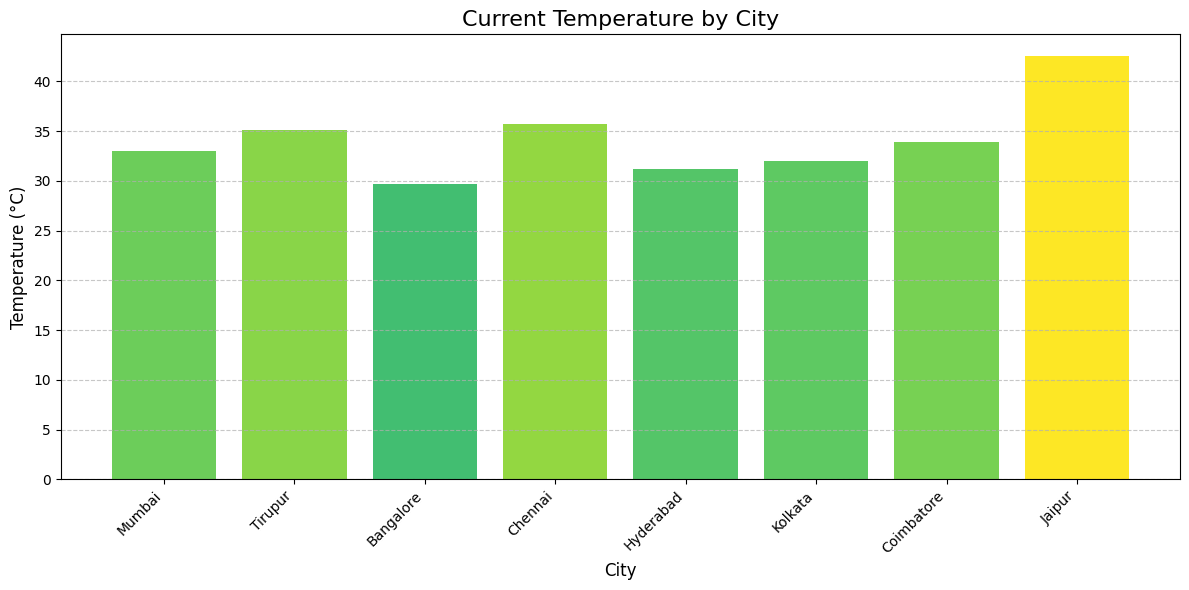

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(weather_df['city'], weather_df['temperature'], color=plt.cm.viridis(weather_df['temperature'] / weather_df['temperature'].max()))

plt.title('Current Temperature by City', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()